# Exploratory Data Analysis (CIC-IDS2017)

[Dataset Link](https://www.unb.ca/cic/datasets/ids-2017.html)

# CICTONIOT: Visão Geral

O CICTONIOT é um conjunto de dados desenvolvido pelo Canadian Institute for Cybersecurity para pesquisas em detecção de intrusões. Ele combina tráfego benigno realista com ataques simulados, permitindo avaliações controladas e comparáveis de métodos de análise e defesa em redes.

## Características Principais

- Milhões de fluxos de rede com cerca de 80 atributos por fluxo.
- Coleta realizada ao longo de cinco dias, cada um contendo diferentes cenários de tráfego e ataques.
- Disponível em PCAP e em versões CSV pré-processadas, amplamente utilizadas em machine learning.
- Atributos incluem estatísticas de pacotes, taxas de transferência, flags de protocolo e métricas temporais.

## Relevância Científica

O dataset tornou-se referência por oferecer diversidade de ataques, rotulagem confiável e cenário próximo de redes reais. É adequado para estudos supervisionados, não supervisionados e híbridos, facilitando comparações reprodutíveis entre diferentes abordagens de detecção de intrusões.

## Limitações

- Desbalanceamento entre classes, especialmente em ataques raros.
- Ambiente controlado que não incorpora toda a complexidade de redes corporativas reais.
- Alguns ataques são simulados de forma automatizada, podendo simplificar certos padrões comportamentais.

## Tipos de Ataques 

### Força Bruta
Ataques baseados em tentativas repetidas de adivinhar credenciais de acesso, como FTP e SSH, explorando repetição rápida e automatizada.

### Scanning
Processos de reconhecimento que identificam portas abertas, serviços ativos e potenciais vulnerabilidades. Costumam preceder etapas de intrusão.

### DDoS e DoS
Ataques que sobrecarregam serviços com tráfego excessivo, causando indisponibilidade. Incluem variantes de alta taxa (Hulk, GoldenEye) e variantes lentas (Slowloris, SlowHTTPTest).

### Ataques Web
Exploram vulnerabilidades em aplicações web, como injeção de comandos ou scripts maliciosos (XSS), visando comprometer sistemas pela camada de aplicação.

### Botnet
Atividade típica de máquinas comprometidas que se comunicam com servidores de comando e controlo e executam ações automatizadas.

### Exploits Específicos
Explorações direcionadas a vulnerabilidades concretas, como o Heartbleed, que permitia extrair dados sensíveis da memória de sistemas com OpenSSL vulnerável.


In [1]:
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
sns.set(style='darkgrid')

# pd.set_option('display.max_columns', 50)
# pd.set_option('display.width', 1000)
# sns.set(style="whitegrid")

DATA_PATH = "data/processed/CICTONIOT"

df = dd.read_parquet(DATA_PATH)


In [2]:
print("Classes originais:")
print(df["Label"].astype(str).str.strip().value_counts().compute())


Classes originais:
Label
0    2123867
1    2723632
Name: count, dtype: int64


In [2]:
print(df.head().to_string())


   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean   Fwd IAT Std  Fwd IAT Max  Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean  Bwd IAT Std  Bwd IAT Max  Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Packet Length Min  Packet Length Max  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG Flag Count  CWE Flag Count  ECE Flag Count  Down/Up Ratio  Avg Packet Size  Avg Fwd Segment Size  Avg Bwd Segment Size  Fwd Avg Bytes/Bulk  Fwd Avg Packet

### Sample do Dataset

In [3]:
sample_df = df.sample(frac=0.1, random_state=42).compute()
sample_df.head(n=100)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Attack
3230142,6,154,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.556358e+15,0.000000e+00,1.556358e+15,1.556358e+15,0,Benign
1259141,6,47962,5,4,356.0,1282.0,356.0,0.0,71.199997,159.208038,...,0.0,0.0,0.0,0.0,1.556346e+15,0.000000e+00,1.556346e+15,1.556346e+15,1,injection
505386,0,82211512,2,0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,7.780139e+14,1.100278e+15,1.556028e+15,8.221151e+07,0,Benign
1090701,6,243365,5,2,305.0,561.0,305.0,0.0,61.000000,136.400146,...,0.0,0.0,0.0,0.0,1.556344e+15,0.000000e+00,1.556344e+15,1.556344e+15,1,injection
3643746,6,18224,3,4,433.0,1282.0,433.0,0.0,144.333328,249.992661,...,0.0,0.0,0.0,0.0,1.556360e+15,0.000000e+00,1.556360e+15,1.556360e+15,1,xss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466618,17,5193,2,2,74.0,90.0,37.0,37.0,37.000000,0.000000,...,0.0,0.0,0.0,0.0,1.556345e+15,0.000000e+00,1.556345e+15,1.556345e+15,1,xss
1763880,17,17,2,2,74.0,90.0,37.0,37.0,37.000000,0.000000,...,0.0,0.0,0.0,0.0,1.556349e+15,0.000000e+00,1.556349e+15,1.556349e+15,1,xss
2601474,6,41902,3,4,437.0,1282.0,437.0,0.0,145.666672,252.302063,...,0.0,0.0,0.0,0.0,1.556354e+15,0.000000e+00,1.556354e+15,1.556354e+15,1,xss
3836805,6,863060,6,4,2581.0,1380.0,1448.0,0.0,430.166656,673.814941,...,0.0,0.0,0.0,0.0,1.556362e+15,0.000000e+00,1.556362e+15,1.556362e+15,1,xss


In [4]:
print("Classes originais:")
print(df["Label"].astype(str).str.strip().value_counts())


Classes originais:
Dask Series Structure:
npartitions=1
    int64
      ...
Dask Name: valuecounts, 5 expressions
Expr=(FunctionMap(frame=AsType(frame=ReadParquetFSSpec(0e44500)['Label'], dtypes=<class 'str'>), accessor='str', attr='strip', args=(), kwargs={})).valuecounts(split_out=True)


### Dimensão do Dataset

In [5]:
rows = df.shape[0].compute()
cols = df.shape[1]

print(f'Number of rows: {rows}')
print(f'Number of columns: {cols}')
print(f'Total cells: {rows * cols}')


Number of rows: 4847499
Number of columns: 79
Total cells: 382952421


In [6]:
df.compute().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4847499 entries, 0 to 4847498
Data columns (total 79 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   Protocol                  int8    
 1   Flow Duration             int64   
 2   Total Fwd Packets         int32   
 3   Total Backward Packets    int32   
 4   Fwd Packets Length Total  float32 
 5   Bwd Packets Length Total  float32 
 6   Fwd Packet Length Max     float32 
 7   Fwd Packet Length Min     float32 
 8   Fwd Packet Length Mean    float32 
 9   Fwd Packet Length Std     float32 
 10  Bwd Packet Length Max     float32 
 11  Bwd Packet Length Min     float32 
 12  Bwd Packet Length Mean    float32 
 13  Bwd Packet Length Std     float32 
 14  Flow Bytes/s              float32 
 15  Flow Packets/s            float64 
 16  Flow IAT Mean             float32 
 17  Flow IAT Std              float32 
 18  Flow IAT Max              float32 
 19  Flow IAT Min              float32 
 20  Fw

##### Todas as features são do tipo string

In [7]:
# Percentagem de valores nulos por coluna
nulls = (df.isnull().mean() * 100).compute().sort_values(ascending=False)
# Mostrar apenas colunas com valores nulos
print(nulls[nulls > 0])


Series([], dtype: float64)


In [8]:
# tamanho total
total = df.shape[0].compute()

# número de ocorrências de cada linha
counts = df.map_partitions(lambda pdf: pdf.value_counts()).compute()

# total de duplicados (ocorrências > 1)
duplicated_rows = counts[counts > 1].sum() - counts[counts > 1].size

dup_ratio = duplicated_rows / total
print(f"Duplicados: {dup_ratio:.2%}")


KeyboardInterrupt: 

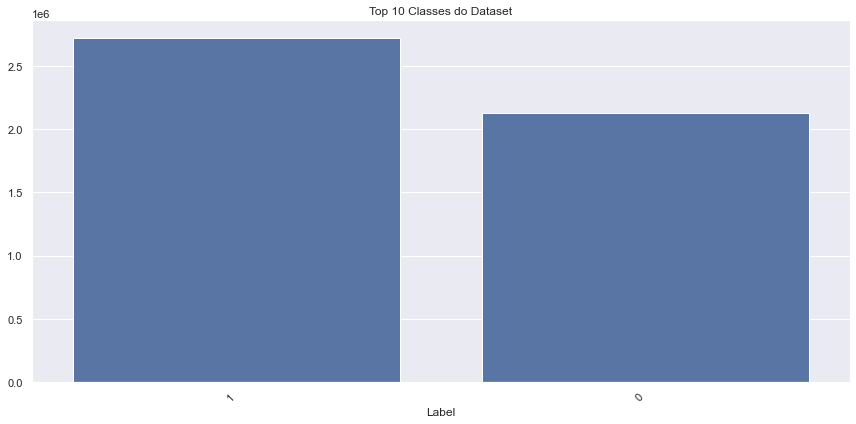

In [ ]:
# Remove espaços antes e depois de todos os nomes de colunas
df.columns = df.columns.str.strip()

# Convert to pandas first for value_counts and handle string column
labels = df['Label'].astype(str).compute().value_counts()
top_n = 10
labels_top = labels.sort_values(ascending=False).head(top_n)

plt.figure(figsize=(12,6))
sns.barplot(x=labels_top.index, y=labels_top.values)
plt.title(f"Top {top_n} Classes do Dataset")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Estatísticas das colunas numéricas
df.describe().compute().T.head(100)


,count,mean,std,min,25%,50%,75%,max
Protocol,4847499.0,7.045429e+00,4.372779e+00,0.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,1.700000e+01
Flow Duration,4847499.0,5.290554e+06,1.295966e+08,-4.581762e+10,2.307000e+03,3.286300e+04,6.805260e+05,1.200000e+08
Total Fwd Packets,4847499.0,5.887697e+00,8.542685e+02,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,1.230237e+06
Total Backward Packets,4847499.0,3.823593e+00,5.968234e+02,0.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,6.707620e+05
Fwd Packets Length Total,4847499.0,8.053910e+02,1.145956e+04,0.000000e+00,0.000000e+00,8.000000e+01,5.230000e+02,1.406402e+07
...,...,...,...,...,...,...,...,...
Idle Mean,4847499.0,1.477805e+15,2.495323e+14,1.377379e+13,1.556346e+15,1.556354e+15,1.556362e+15,1.556549e+15
Idle Std,4847499.0,9.696082e+13,3.055254e+14,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.100646e+15
Idle Max,4847499.0,1.556356e+15,8.016631e+10,1.554199e+15,1.556347e+15,1.556356e+15,1.556363e+15,1.556549e+15
Idle Min,4847499.0,1.411786e+15,4.517839e+14,5.000004e+06,1.556346e+15,1.556354e+15,1.556362e+15,1.556549e+15


In [ ]:
# Converter Dask → Pandas
encoded = df.compute() if not isinstance(df, pd.DataFrame) else df.copy()
encoded.columns = encoded.columns.str.strip()

# Separar a Label
label_col = encoded['Label'].copy()

# Converter apenas as features para numérico
features = encoded.drop(columns=['Label'], errors='ignore')
for col in features.columns:
    features[col] = pd.to_numeric(features[col], errors='coerce')

# Juntar novamente (mantendo a Label original)
encoded = pd.concat([features, label_col], axis=1)

# Codificar Label (sem alterar as classes originais)
encoded['Label_encoded'] = encoded['Label'].astype('category').cat.codes

# Calcular correlação com Label_encoded
corr_target = encoded.corr(numeric_only=True)['Label_encoded'].sort_values(ascending=False)
corr_target.head(50)

Label_encoded               1.000000
Label                       1.000000
Protocol                    0.377964
Fwd Packet Length Max       0.335807
Fwd Packet Length Std       0.328672
Subflow Fwd Bytes           0.323300
Avg Fwd Segment Size        0.318789
Fwd Packet Length Mean      0.318789
Init Fwd Win Bytes          0.315734
Packet Length Max           0.305427
Packet Length Std           0.294096
Avg Packet Size             0.290775
Bwd Packet Length Std       0.290055
Packet Length Mean          0.289763
Bwd Packet Length Max       0.271631
Avg Bwd Segment Size        0.259248
Bwd Packet Length Mean      0.259248
Idle Mean                   0.252373
Idle Min                    0.249412
Packet Length Variance      0.245361
Init Bwd Win Bytes          0.178368
Subflow Bwd Bytes           0.178024
Packet Length Min           0.112320
Bwd Packet Length Min       0.038542
Fwd Packets Length Total    0.027129
Fwd Packet Length Min       0.026039
Bwd IAT Max                 0.016788
B

           count      mean         std  min  25%  50%  75%       max
Label                                                               
1      2723632.0  1.326832    5.234499  0.0  0.0  2.0  2.0    2034.0
0      2123867.0  0.959101  118.147553  0.0  0.0  0.0  1.0  165078.0


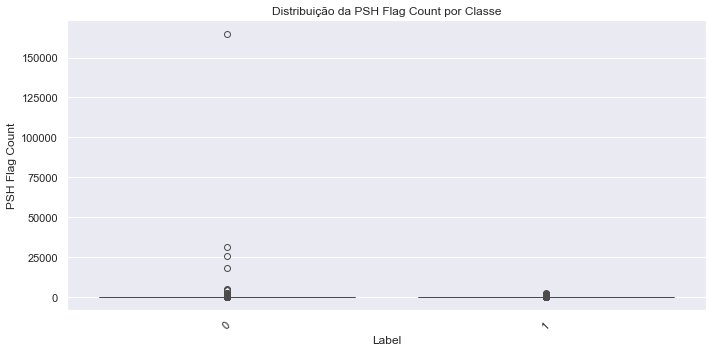

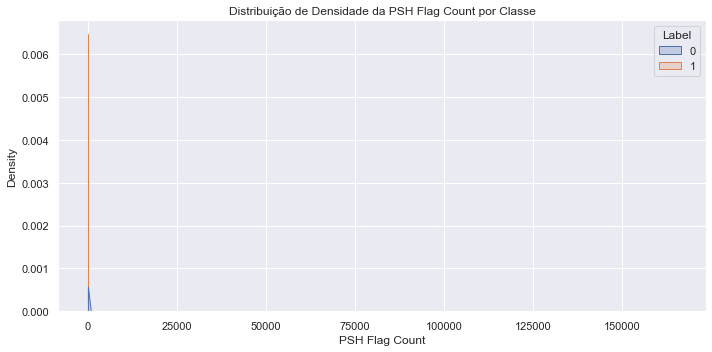

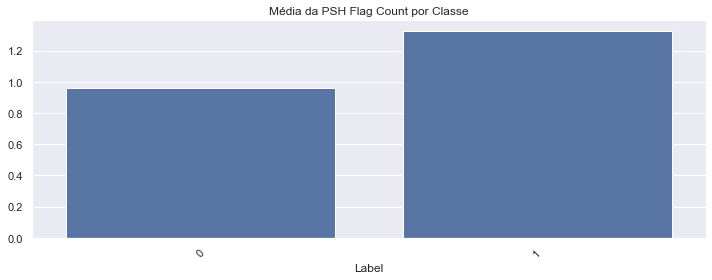

In [ ]:
# garantir que Label e PSH Flag Count existem
if 'PSH Flag Count' not in encoded.columns:
    raise KeyError("Coluna 'PSH Flag Count' não encontrada no DataFrame.")

# converter para numérico se necessário
encoded['PSH Flag Count'] = pd.to_numeric(encoded['PSH Flag Count'], errors='coerce')

# remover valores nulos
feat_df = encoded[['Label', 'PSH Flag Count']].dropna()

# estatísticas descritivas por classe
stats = feat_df.groupby('Label')['PSH Flag Count'].describe().sort_values('mean', ascending=False)
print(stats)

# boxplot por classe
plt.figure(figsize=(10,5))
sns.boxplot(data=feat_df, x='Label', y='PSH Flag Count')
plt.title("Distribuição da PSH Flag Count por Classe")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# densidade / histograma por classe
plt.figure(figsize=(10,5))
sns.kdeplot(data=feat_df, x='PSH Flag Count', hue='Label', common_norm=False, fill=True)
plt.title("Distribuição de Densidade da PSH Flag Count por Classe")
plt.tight_layout()
plt.show()

# valores médios por classe
plt.figure(figsize=(10,4))
mean_values = feat_df.groupby('Label')['PSH Flag Count'].mean().sort_values(ascending=False)
sns.barplot(x=mean_values.index, y=mean_values.values)
plt.title("Média da PSH Flag Count por Classe")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import mannwhitneyu

# teste estatístico entre BENIGN e as restantes classes (exemplo)
labels = feat_df['Label'].unique()
if 'BENIGN' in labels:
    benign = feat_df.loc[feat_df['Label'] == 'BENIGN', 'PSH Flag Count']
    for label in labels:
        if label != 'BENIGN':
            attack = feat_df.loc[feat_df['Label'] == label, 'PSH Flag Count']
            stat, p = mannwhitneyu(benign, attack, alternative='two-sided')
            print(f"Teste BENIGN vs {label}: U={stat:.0f}, p={p:.3e}")

#### Patterns

In [ ]:
attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

df['Attack Type'] = df['Label'].map(attack_map, meta=('Attack Type', 'object'))


df['Attack Type'].value_counts().compute().sort_values(ascending=False)


Series([], Name: count, dtype: int64)

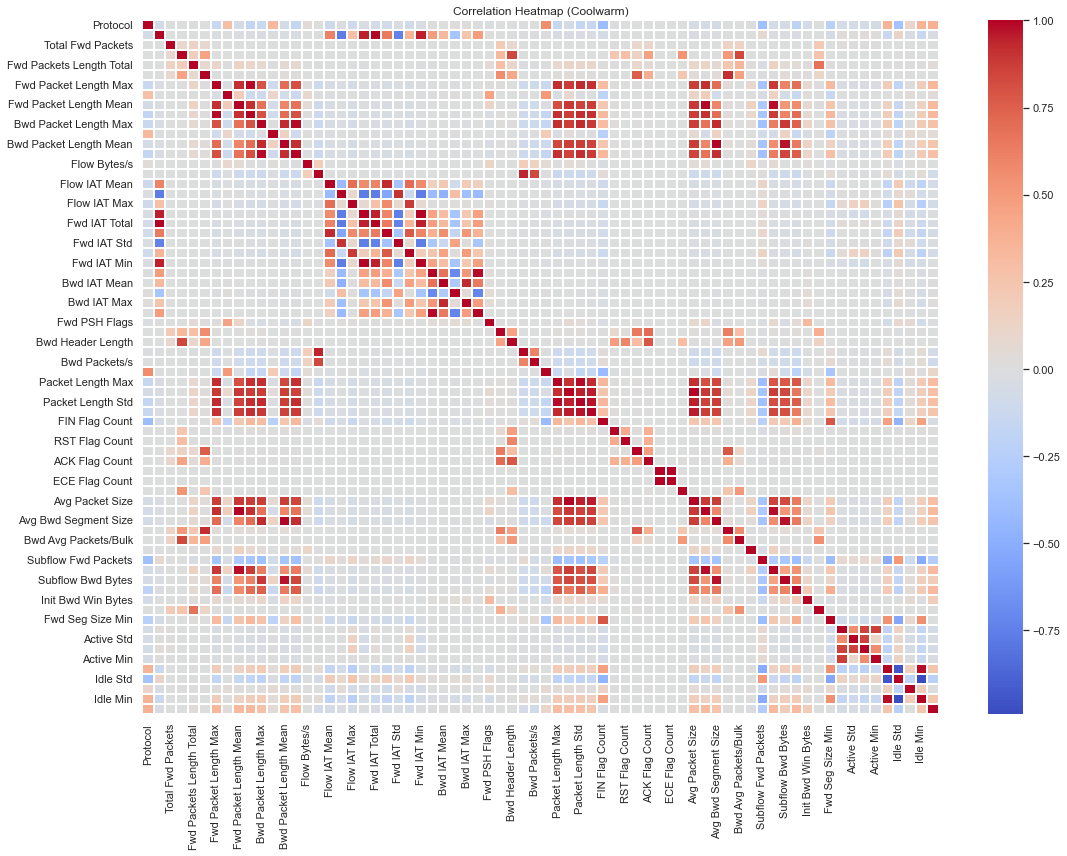

In [ ]:
pdf = df.compute()

y = pdf["Label"]
X = pdf.drop(columns=["Label"])
X = X.apply(pd.to_numeric, errors='coerce')

pdf_clean = X.copy()
pdf_clean["Label_encoded"] = y.astype("category").cat.codes

corr = pdf_clean.corr().round(2)
corr_clean = corr.dropna(axis=0, how="all").dropna(axis=1, how="all")


plt.figure(figsize=(16, 12))
sns.heatmap(corr_clean, cmap='coolwarm', annot=False, linewidths=0.1)
plt.title("Correlation Heatmap (Coolwarm)")
plt.tight_layout()
plt.show()

In [ ]:
corr_target = corr_clean["Label_encoded"].abs().sort_values(ascending=False)
corr_target


Label_encoded             1.00
Protocol                  0.38
Fwd Packet Length Max     0.34
Fwd Packet Length Std     0.33
Avg Fwd Segment Size      0.32
                          ... 
Total Backward Packets    0.00
Bwd Header Length         0.00
Fwd Header Length         0.00
Bwd IAT Min               0.00
Total Fwd Packets         0.00
Name: Label_encoded, Length: 70, dtype: float64

<ipython-input-16-51de2073edc8>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topN.values, y=topN.index, orient='h', palette='coolwarm')


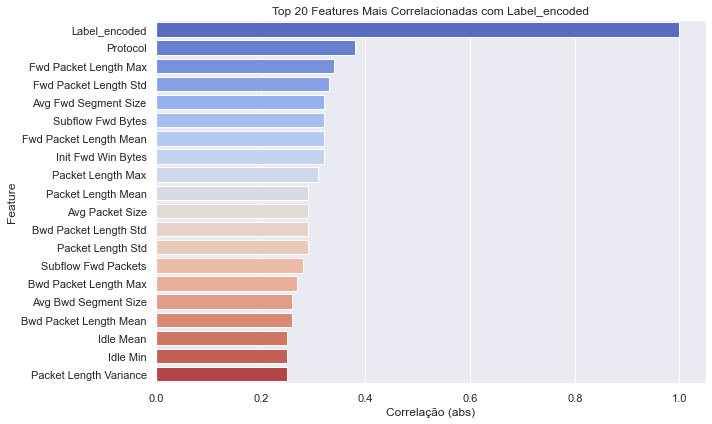

In [ ]:
topN = corr_target.head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=topN.values, y=topN.index, orient='h', palette='coolwarm')
plt.title("Top 20 Features Mais Correlacionadas com Label_encoded")
plt.xlabel("Correlação (abs)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


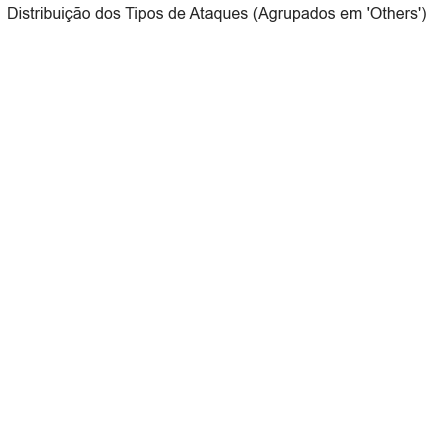

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================
# 1) Mapa de agrupamento inicial
# =====================================================

attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

# Criar coluna agrupada
pdf["Attack Type"] = pdf["Label"].map(attack_map)

# =====================================================
# 2) Calcular contagens
# =====================================================

counts = pdf["Attack Type"].value_counts()

# =====================================================
# 3) Aplicar threshold → categorias pequenas → "Others"
# =====================================================

threshold = 0.005   # 0,5% do dataset (ajusta como quiseres)

total = counts.sum()
small_classes = counts[counts < total * threshold].index

# Substituir classes pequenas por "Others"
pdf["Attack Grouped"] = pdf["Attack Type"].replace({c: "Others" for c in small_classes})

# Contagem final
counts_grouped = pdf["Attack Grouped"].value_counts()

# =====================================================
# 4) Pie Chart Melhorado
# =====================================================

explode = [0.05 if v < counts_grouped.sum()*0.05 else 0 for v in counts_grouped]

plt.figure(figsize=(6, 6))
plt.pie(
    counts_grouped.values,
    labels=counts_grouped.index,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    startangle=140,
    pctdistance=0.8,
    labeldistance=1.1,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)

plt.title("Distribuição dos Tipos de Ataques (Agrupados em 'Others')", fontsize=16)
plt.tight_layout()
plt.show()


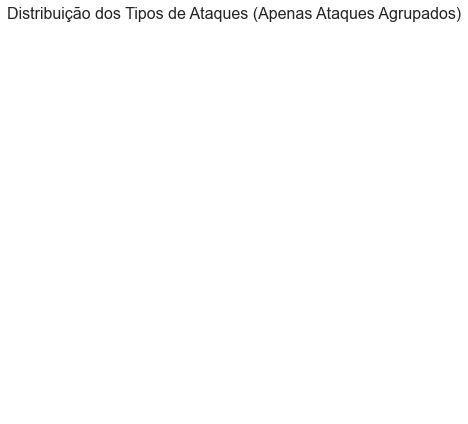

In [ ]:

attacks_only = pdf[pdf["Attack Type"] != "BENIGN"]

# Contagens
counts = attacks_only["Attack Type"].value_counts()

# =====================================================
# 3) Threshold → classes pequenas viram "Others"
# =====================================================

threshold = 0.005  # 2% dos ataques

total = counts.sum()
small_classes = counts[counts < total * threshold].index

# Criar coluna final agrupada
attacks_only["Attack Grouped"] = attacks_only["Attack Type"].replace(
    {c: "Others" for c in small_classes}
)

counts_grouped = attacks_only["Attack Grouped"].value_counts()

# =====================================================
# 4) Gráfico de Pizza – apenas ataques
# =====================================================


plt.figure(figsize=(6, 6))
plt.pie(
    counts_grouped.values,
    labels=counts_grouped.index,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    startangle=140,
    pctdistance=0.8,
    labeldistance=1.1,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)

plt.title("Distribuição dos Tipos de Ataques (Apenas Ataques Agrupados)", fontsize=16)
plt.tight_layout()
plt.show()
